# Battery capacity fade and remaining useful life

An open-data investigation, built in short steps. Each step does one thing,
ends with a plot, and a note on what the plot shows.

**The question:** from cheap per-cycle summary numbers (how long a discharge
took, how fast the voltage fell through a fixed band, charge timings), can I
predict how many cycles a lithium-ion cell has left - and have it hold up on
cells the model was never fitted to?

**Dataset:** "Battery Remaining Useful Life (RUL)", Kaggle
`ignaciovinuales/battery-remaining-useful-life-rul`, licence CC0-1.0. Derived
from NASA-style randomised-load cell cycling (the widely used "TII" processed
feature set). One row = one charge/discharge cycle of one cell.

**Steps**

1. Load the data
2. What the columns mean
3. Separate the individual cells
4. What to expect physically - written down before modelling
5. Data quality - find the bad rows
6. Clean with physical limits
7. How each feature moves as the cell ages
8. Which features correlate with remaining life
9. A one-feature baseline model
10. Do more features help? (they don't - and why)
11. Where the model fails
12. Conclusion and limits

**Credentials note:** no API keys or tokens are in this notebook. On Kaggle the
dataset is attached through the UI; locally it is pulled with the Kaggle CLI
using the machine's own credential file.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

---
## Step 1 - Load the data

### 1a. Find the file (Kaggle mounts it under /kaggle/input; locally I keep a copy)

In [2]:
import glob

CANDIDATES = (
    glob.glob("/kaggle/input/**/Battery_RUL.csv", recursive=True)
    + glob.glob("/kaggle/input/**/*.csv", recursive=True)
    + [
        "data/Battery_RUL.csv",
        os.path.expanduser("~/KaggleLab/data/Battery_RUL.csv"),
        "D:/Claude/KaggleLab/data/Battery_RUL.csv",
    ]
)
BATTERY_CSV = next((p for p in CANDIDATES if os.path.exists(p)), None)
print("using:", BATTERY_CSV)
assert BATTERY_CSV, "Battery_RUL.csv not found - attach the Kaggle dataset or place it under data/"

using: data/Battery_RUL.csv


### 1b. Read it and look at the first rows

In [3]:
df = pd.read_csv(BATTERY_CSV)
print("shape:", df.shape)
df.head()

shape: (15064, 9)


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


### 1c. Plot - the target variable across the whole file

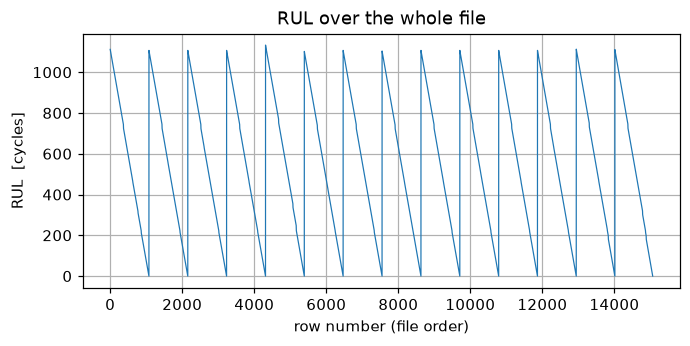

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(df["RUL"].values, lw=0.8)
ax.set_xlabel("row number (file order)")
ax.set_ylabel("RUL  [cycles]")
ax.set_title("RUL over the whole file")
plt.show()

**What the plot shows**

* RUL ("remaining useful life") counts down within a cell, then jumps back up.
  Each sawtooth is one cell, cycled from near-new to end-of-life.
* So the file is several cells concatenated. Step 3 separates them.

---
## Step 2 - What the columns mean

The dataset has no raw voltage/current traces, only these per-cycle summaries.
So any resistance or capacity statement below is an *inference from timing*,
not a direct measurement.

| column | meaning | unit |
|---|---|---|
| `Cycle_Index` | cycle number for that cell | - |
| `Discharge Time (s)` | length of the discharge phase | s |
| `Decrement 3.6-3.4V (s)` | time for terminal voltage to fall from 3.6 to 3.4 V during discharge | s |
| `Max. Voltage Dischar. (V)` | highest terminal voltage during discharge | V |
| `Min. Voltage Charg. (V)` | lowest terminal voltage during charge | V |
| `Time at 4.15V (s)` | time spent near the top-of-charge voltage plateau | s |
| `Time constant current (s)` | length of the constant-current charge phase | s |
| `Charging time (s)` | total charge duration | s |
| `RUL` | cycles remaining until end-of-life | cycles (**the target**) |

---
## Step 3 - Separate the individual cells

Split the file wherever `RUL` jumps back up (a new cell starting near full life).

### 3a. Detect the boundaries and label each cell

In [5]:
new_cell = df["RUL"].diff().fillna(-1) > 0     # True where RUL jumps up
df["cell_id"] = new_cell.cumsum()
cycle_counts = df.groupby("cell_id").size()
print(f"found {df['cell_id'].nunique()} cells")
print(cycle_counts.to_string())

found 14 cells
cell_id
0     1076
1     1079
2     1077
3     1081
4     1077
5     1078
6     1081
7     1080
8     1079
9     1079
10    1077
11    1077
12    1072
13    1051


### 3b. Plot - cycles of life per cell

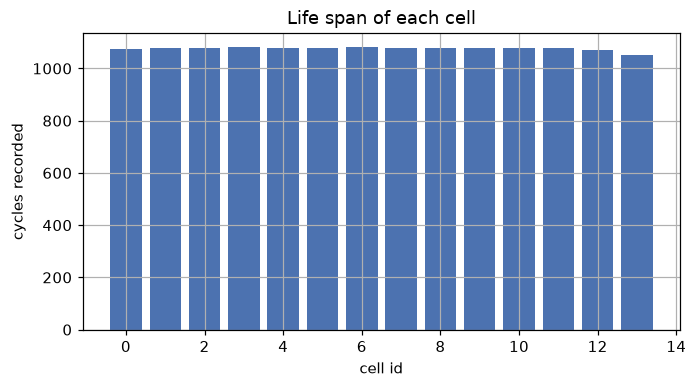

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(cycle_counts.index, cycle_counts.values, color="#4C72B0")
ax.set_xlabel("cell id")
ax.set_ylabel("cycles recorded")
ax.set_title("Life span of each cell")
plt.show()

**What the plot shows**

* 14 cells, each cycled for very close to the same life - about 1080 cycles.
* That near-constant lifetime matters: it means `Cycle_Index` alone almost
  determines RUL (`RUL` is roughly `1080 - Cycle_Index`). Predicting cycles-left
  from cycle-number is circular, so `Cycle_Index` is left out of every model
  below. The real question is whether the *condition* features carry the signal.

---
## Step 4 - What to expect physically (written down before modelling)

As a lithium-ion cell ages, two things happen:

* **capacity fade** - loss of cyclable lithium and active material, so the cell
  holds less charge;
* **impedance rise** - a growing surface film and contact resistance, so the
  voltage responds more sharply to current.

Predictions for the features:

1. **Capacity fade shortens every duration.** With less charge to move in and
   out, `Discharge Time`, `Time constant current`, `Charging time` and
   `Time at 4.15V` all **fall**.
2. **Impedance rise speeds the voltage swings.** `Decrement 3.6-3.4V` (time to
   fall through a fixed voltage band) **falls**; `Max. Voltage Dischar.`
   **falls** because the cell can't hold as high a terminal voltage under load.
3. **One feature should rise.** `Min. Voltage Charg.` - the lowest voltage seen
   during charge - **rises** with age, because the larger IR step at the start
   of charge lifts the whole charge voltage.

So: nearly everything falls with age; `Min. Voltage Charg.` is the exception.

---
## Step 5 - Data quality: find the bad rows

### 5a. Missing values and the range of each column

In [7]:
print("missing values per column:")
print(df.isna().sum().to_string())
print()
print("min / max of each column:")
print(df.describe().T[["min", "max"]].to_string())

missing values per column:
Cycle_Index                  0
Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
cell_id                      0

min / max of each column:
                                  min         max
Cycle_Index                     1.000    1134.000
Discharge Time (s)              8.690  958320.370
Decrement 3.6-3.4V (s)    -397645.908  406703.768
Max. Voltage Dischar. (V)       3.043       4.363
Min. Voltage Charg. (V)         3.022       4.379
Time at 4.15V (s)            -113.584  245101.117
Time constant current (s)       5.980  880728.100
Charging time (s)               5.980  880728.100
RUL                             0.000    1133.000
cell_id                         0.000      13.000


### 5b. Count the physically-impossible values per column

In [8]:
PHYS = {  # plausible (low, high) for one cycle
    "Discharge Time (s)": (60, 12000),
    "Decrement 3.6-3.4V (s)": (1, 5000),
    "Time at 4.15V (s)": (1, 12000),
    "Time constant current (s)": (60, 20000),
    "Charging time (s)": (60, 25000),
    "Max. Voltage Dischar. (V)": (3.0, 4.3),
    "Min. Voltage Charg. (V)": (3.0, 4.3),
}
bad_counts = {c: int((~df[c].between(lo, hi)).sum()) for c, (lo, hi) in PHYS.items()}
for c, n in bad_counts.items():
    print(f"{c:28s} {n:4d} rows outside {PHYS[c]}")

Discharge Time (s)            212 rows outside (60, 12000)
Decrement 3.6-3.4V (s)        130 rows outside (1, 5000)
Time at 4.15V (s)             176 rows outside (1, 12000)
Time constant current (s)     211 rows outside (60, 20000)
Charging time (s)             211 rows outside (60, 25000)
Max. Voltage Dischar. (V)       1 rows outside (3.0, 4.3)
Min. Voltage Charg. (V)         1 rows outside (3.0, 4.3)


### 5c. Plot

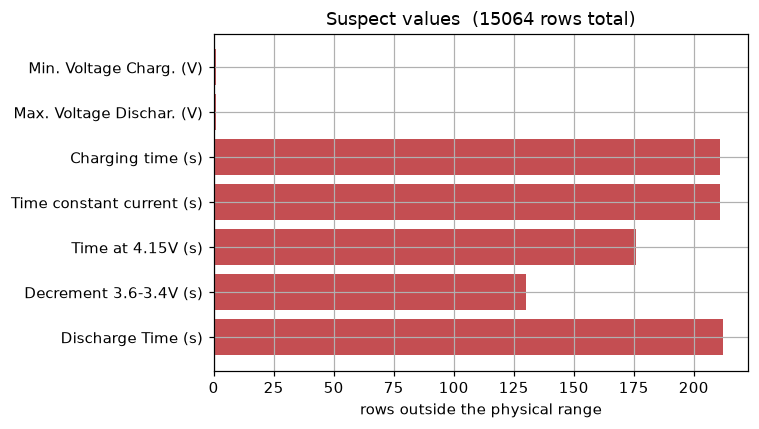

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(list(bad_counts), list(bad_counts.values()), color="#C44E52")
ax.set_xlabel("rows outside the physical range")
ax.set_title(f"Suspect values  ({df.shape[0]} rows total)")
plt.tight_layout()
plt.show()

**What the plot shows**

* A few hundred rows carry values that cannot be real for a single cycle -
  negative durations, or "discharge times" of several days. These are logging
  artefacts or merged cycles, spread across a handful of columns.
* They are a small fraction of ~15000 rows, so trimming them is safe.

---
## Step 6 - Clean with physical limits

Keep only rows where every feature sits inside its plausible range (Step 5a).
This is physically motivated, not blind percentile clipping.

### 6a. Apply the limits

In [10]:
keep = np.ones(len(df), dtype=bool)
for c, (lo, hi) in PHYS.items():
    keep &= df[c].between(lo, hi)
clean = df[keep].reset_index(drop=True)
print(f"kept {keep.sum()} of {len(df)} rows  ({100 * keep.mean():.1f}%)")

kept 14840 of 15064 rows  (98.5%)


### 6b. Plot - rows kept per cell

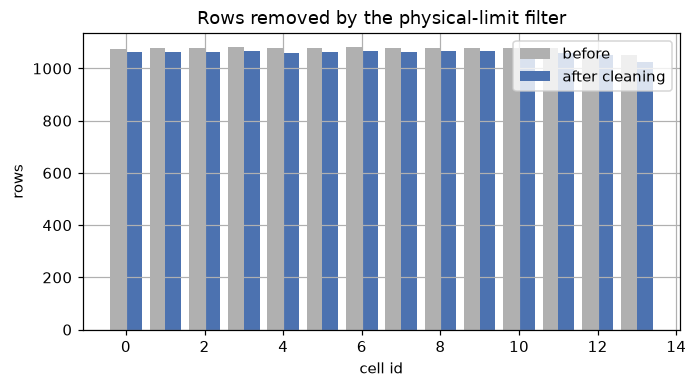

In [11]:
before = df.groupby("cell_id").size()
after = clean.groupby("cell_id").size()

fig, ax = plt.subplots(figsize=(7, 3.5))
w = 0.4
ax.bar(before.index - w / 2, before.values, w, label="before", color="#B0B0B0")
ax.bar(after.index + w / 2, after.reindex(before.index).fillna(0).values, w,
       label="after cleaning", color="#4C72B0")
ax.set_xlabel("cell id")
ax.set_ylabel("rows")
ax.set_title("Rows removed by the physical-limit filter")
ax.legend()
plt.show()

**What the plot shows**

* Cleaning removes only a thin slice from each cell and leaves every cell with a
  near-complete life history. No cell is gutted, so the per-cell analysis below
  is not biased by the filter.

---
## Step 7 - How each feature moves as the cell ages

Plot every condition feature against cycle number, one line per cell, and read
it against the predictions in Step 4.

### 7a. The condition features (Cycle_Index and the target excluded)

In [12]:
feat_cols = [c for c in clean.columns
             if c not in ("RUL", "cell_id", "Cycle_Index")]
print(feat_cols)

['Discharge Time (s)', 'Decrement 3.6-3.4V (s)', 'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)', 'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)']


### 7b. Plot - trajectories, one panel per feature

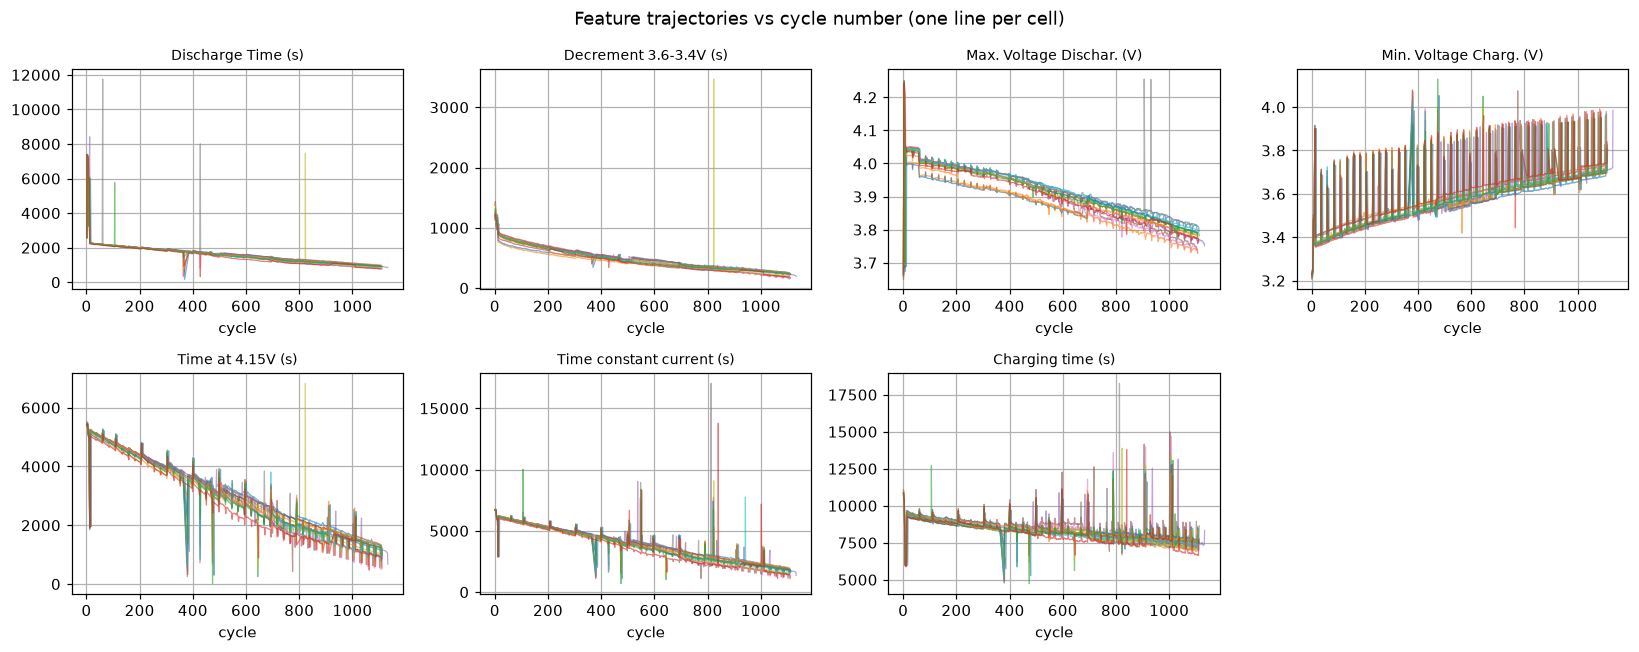

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.ravel(), feat_cols):
    for _, g in clean.groupby("cell_id"):
        ax.plot(g["Cycle_Index"], g[col], lw=0.8, alpha=0.6)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("cycle")
for ax in axes.ravel()[len(feat_cols):]:
    ax.axis("off")
fig.suptitle("Feature trajectories vs cycle number (one line per cell)")
fig.tight_layout()
plt.show()

**What the plot shows**

* Every duration - discharge time, CC-charge time, charging time, time at
  4.15 V - trends **down** with age, and so do the two discharge-voltage
  features. Capacity fade dominates: the aged cell simply moves less charge.
* `Min. Voltage Charg.` is the one feature that trends **up** - the impedance
  signature from prediction 3.
* The trajectories are consistent cell to cell, so the pattern is real.

---
## Step 8 - Which features correlate with remaining life

### 8a. Pearson correlation of each feature with RUL

In [14]:
corr = clean[feat_cols + ["RUL"]].corr()["RUL"].drop("RUL").sort_values()
print(corr.to_string())

Min. Voltage Charg. (V)     -0.791727
Charging time (s)            0.725799
Discharge Time (s)           0.774642
Max. Voltage Dischar. (V)    0.928263
Decrement 3.6-3.4V (s)       0.940662
Time constant current (s)    0.968281
Time at 4.15V (s)            0.978711


### 8b. Plot

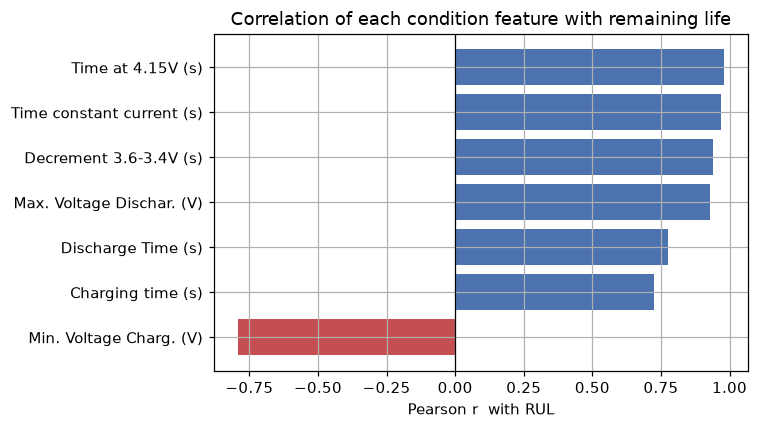

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Pearson r  with RUL")
ax.set_title("Correlation of each condition feature with remaining life")
plt.tight_layout()
plt.show()

**What the plot shows**

* Every feature that *falls* with age is **positively** correlated with RUL -
  a high value means a young cell with life left.
* `Min. Voltage Charg.`, which *rises* with age, is the only **negative** one.
* All signs match Step 4. `Time at 4.15V` is the single strongest predictor
  ($r \approx 0.98$): the charge accepted in the final voltage window is close
  to a direct read-out of remaining capacity.

---
## Step 9 - A one-feature baseline model

Start with the strongest single predictor, `Time at 4.15V`, and a straight line:

$$ \widehat{RUL} \;=\; \beta_0 \;+\; \beta_1 \, x_{\text{time at 4.15V}} $$

**Validation is by cell, not by row:** three whole cells are held out. A random
row split would leak, because consecutive cycles of one cell are nearly
identical.

### 9a. Split the cells

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

cells = sorted(clean["cell_id"].unique())
rng = np.random.default_rng(42)
test_cells = sorted(rng.choice(cells, size=3, replace=False))
train_cells = [c for c in cells if c not in test_cells]
train = clean[clean["cell_id"].isin(train_cells)]
test = clean[clean["cell_id"].isin(test_cells)]
print("held-out cells:", test_cells)
print(f"train rows {len(train)}, test rows {len(test)}")

held-out cells: [np.int64(1), np.int64(9), np.int64(10)]
train rows 11647, test rows 3193


### 9b. Fit on one feature

In [17]:
f1 = ["Time at 4.15V (s)"]
scaler1 = StandardScaler().fit(train[f1])
lr1 = LinearRegression().fit(scaler1.transform(train[f1]), train["RUL"])

pred1_train = lr1.predict(scaler1.transform(train[f1]))
pred1_test = lr1.predict(scaler1.transform(test[f1]))

print(f"slope: {lr1.coef_[0]:+.0f} cycles per std-dev of 'Time at 4.15V'")
print(f"train : R2 = {r2_score(train['RUL'], pred1_train):.3f}   "
      f"MAE = {mean_absolute_error(train['RUL'], pred1_train):.0f} cycles")
print(f"test  : R2 = {r2_score(test['RUL'], pred1_test):.3f}   "
      f"MAE = {mean_absolute_error(test['RUL'], pred1_test):.0f} cycles  "
      f"(~{mean_absolute_error(test['RUL'], pred1_test)/1080:.0%} of a cell's life)")

slope: +315 cycles per std-dev of 'Time at 4.15V'
train : R2 = 0.958   MAE = 42 cycles
test  : R2 = 0.959   MAE = 44 cycles  (~4% of a cell's life)


### 9c. Plot - predicted vs true on the held-out cells

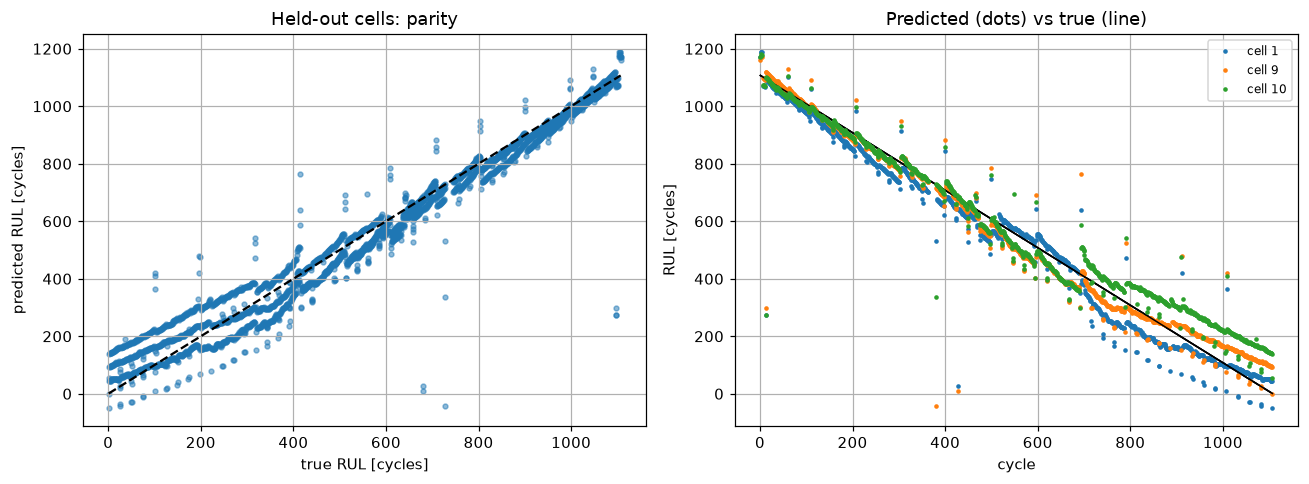

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].scatter(test["RUL"], pred1_test, s=10, alpha=0.5)
lim = [test["RUL"].min(), test["RUL"].max()]
ax[0].plot(lim, lim, "k--")
ax[0].set_xlabel("true RUL [cycles]")
ax[0].set_ylabel("predicted RUL [cycles]")
ax[0].set_title("Held-out cells: parity")

for cid, g in test.groupby("cell_id"):
    p = pred1_test[test.index.get_indexer(g.index)]
    ax[1].plot(g["Cycle_Index"], g["RUL"], "k-", lw=1)
    ax[1].plot(g["Cycle_Index"], p, ".", ms=4, label=f"cell {cid}")
ax[1].set_xlabel("cycle")
ax[1].set_ylabel("RUL [cycles]")
ax[1].set_title("Predicted (dots) vs true (line)")
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

**What the plot shows**

* One feature already tracks remaining life on unseen cells to within a few
  percent of total life, with a positive slope - more charge accepted near full
  means a younger cell.
* The scatter widens at low RUL: the model is weakest near end-of-life.

---
## Step 10 - Do more features help? (they don't - and why)

The obvious next move is to throw in the other features. First check how
independent they actually are.

### 10a. Plot - correlation between the condition features

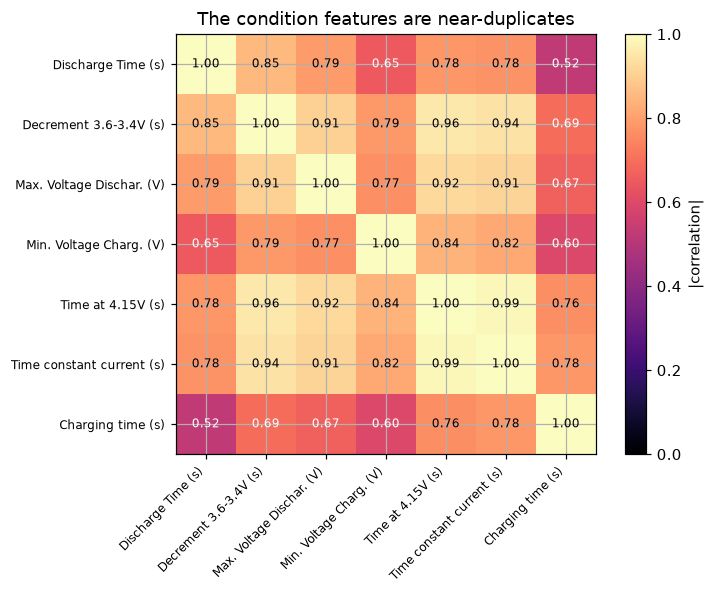

In [19]:
cmat = clean[feat_cols].corr().abs()

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(cmat, vmin=0, vmax=1, cmap="magma")
ax.set_xticks(range(len(feat_cols)))
ax.set_xticklabels(feat_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(feat_cols)))
ax.set_yticklabels(feat_cols, fontsize=8)
for i in range(len(feat_cols)):
    for j in range(len(feat_cols)):
        ax.text(j, i, f"{cmat.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if cmat.iloc[i, j] < 0.7 else "black", fontsize=8)
fig.colorbar(im, label="|correlation|")
ax.set_title("The condition features are near-duplicates")
fig.tight_layout()
plt.show()

### 10b. Fit models with 1, 2 and all 7 features and compare held-out error

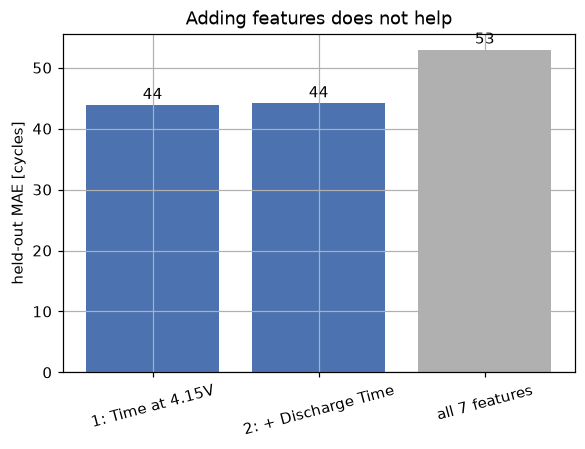

In [20]:
def held_out_mae(feats):
    sc = StandardScaler().fit(train[feats])
    m = LinearRegression().fit(sc.transform(train[feats]), train["RUL"])
    return mean_absolute_error(test["RUL"], m.predict(sc.transform(test[feats])))

sets = {
    "1: Time at 4.15V": ["Time at 4.15V (s)"],
    "2: + Discharge Time": ["Time at 4.15V (s)", "Discharge Time (s)"],
    "all 7 features": feat_cols,
}
maes = {k: held_out_mae(v) for k, v in sets.items()}

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(list(maes), list(maes.values()), color=["#4C72B0", "#4C72B0", "#B0B0B0"])
for i, v in enumerate(maes.values()):
    ax.text(i, v + 1, f"{v:.0f}", ha="center")
ax.set_ylabel("held-out MAE [cycles]")
ax.set_title("Adding features does not help")
plt.xticks(rotation=15)
plt.show()

In [21]:
# what the 7-feature fit does to the coefficients
scA = StandardScaler().fit(train[feat_cols])
lrA = LinearRegression().fit(scA.transform(train[feat_cols]), train["RUL"])
print("7-feature model coefficients:")
for name, coef in zip(feat_cols, lrA.coef_):
    print(f"  {name:28s} {coef:+8.1f}")

7-feature model coefficients:
  Discharge Time (s)              -12.9
  Decrement 3.6-3.4V (s)          +25.7
  Max. Voltage Dischar. (V)       +66.7
  Min. Voltage Charg. (V)         +27.9
  Time at 4.15V (s)              +239.6
  Time constant current (s)       +30.1
  Charging time (s)               -10.3


**What the plots show**

* Most feature pairs correlate above 0.9 (`Time at 4.15V` and
  `Time constant current` reach 0.99). They are all driven by the same thing -
  overall capacity fade - so the data really has about one degree of freedom.
* Adding a second feature leaves the held-out error unchanged; the full
  seven-feature model is *worse* and flips several coefficients to physically
  wrong signs (collinearity splits the shared signal unstably).
* The honest model here is one, maybe two, physically chosen features.

---
## Step 11 - Where the model fails

### 11a. Residuals of the one-feature model on the held-out cells

In [22]:
resid = test["RUL"].values - pred1_test
print(f"residual mean (bias) = {resid.mean():+.0f} cycles")
print(f"residual std         = {resid.std():.0f} cycles")

residual mean (bias) = +6 cycles
residual std         = 65 cycles


### 11b. Plot

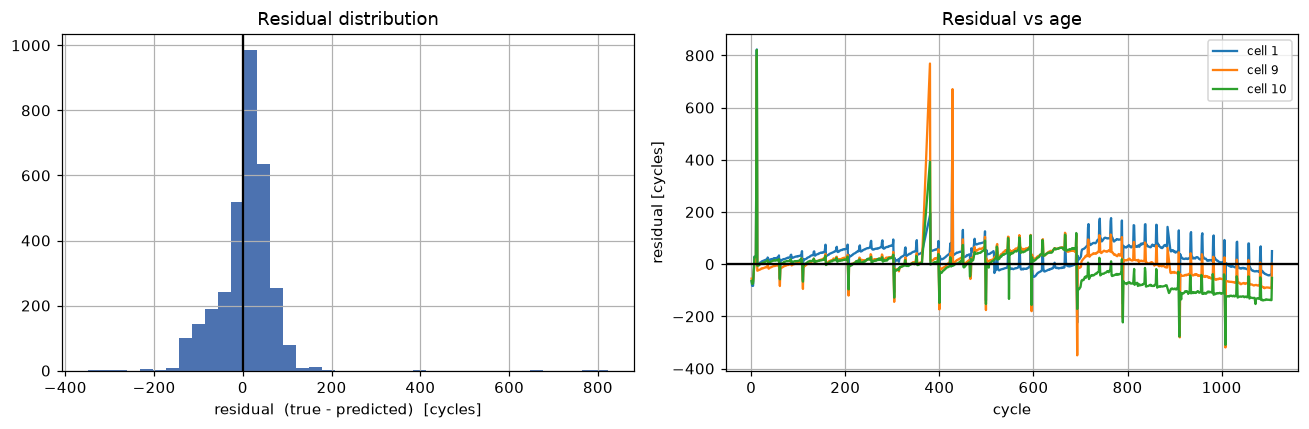

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(resid, bins=40, color="#4C72B0")
ax[0].axvline(0, color="k")
ax[0].set_xlabel("residual  (true - predicted)  [cycles]")
ax[0].set_title("Residual distribution")

for cid, g in test.groupby("cell_id"):
    r = g["RUL"].values - pred1_test[test.index.get_indexer(g.index)]
    ax[1].plot(g["Cycle_Index"], r, label=f"cell {cid}")
ax[1].axhline(0, color="k")
ax[1].set_xlabel("cycle")
ax[1].set_ylabel("residual [cycles]")
ax[1].set_title("Residual vs age")
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

**What the plot shows**

* Residuals are roughly centred but fan out with cycle number: the error is
  largest late in life, where fade accelerates and a straight-line model cannot
  bend.
* A knee-detection or piecewise model is the natural next step.

---
## Step 12 - Conclusion and limits

**What held up**

* A single cheap per-cycle feature - the charge accepted near top-of-charge -
  predicts remaining life on unseen cells to within a few percent of total life,
  with a slope whose sign matches the degradation physics.
* The condition features are near-duplicates of one underlying fade signal, so a
  bigger model does not help and a seven-feature fit is less reliable, not more.

**Limits**

* One cell chemistry, format and test protocol. A different load profile would
  shift every timing feature.
* "End-of-life" is the dataset's own definition, not a measured capacity
  threshold visible here.
* No temperature channel - thermal history, a major ageing driver, is invisible.
* Only 14 cells; the held-out numbers have real variance. Treat them as an order
  of magnitude.

**Next**

* A raw time-series dataset (LG 18650 HG2, or the Oxford Degradation set) to fit
  an actual OCV-SOC curve and a Thevenin equivalent circuit instead of inferring
  resistance from timing.
* A dataset with temperature, to add the thermal term.
* A piecewise / knee model for the end-of-life acceleration seen in Step 11.

---
## Running log

| date | change |
|---|---|
| 2026-09-03 | Created (split out of the old combined notebook). |
| 2026-09-03 | Rebuilt in small steps: parameters -> one calculation -> one plot -> a note. Corrected the ageing story (in this dataset every duration falls with age; only Min. Voltage Charg. rises), moved to a one-feature baseline, added the feature-collinearity heatmap. |